In [1]:
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## creating dataset

In [2]:
np.random.seed(20)

In [3]:
df = pd.DataFrame(data={
    "knows_python": np.random.choice([0, 1], size=1000),
    "knows_genai": np.random.choice([0, 1], size=1000)
})

In [4]:
df

,knows_python,knows_genai
0,1,1
1,0,1
2,1,0
3,1,0
4,0,0
...,...,...
995,1,0
996,1,0
997,1,1
998,1,0


In [5]:
df['placement'] = df.any(axis=1).astype(int)
df.sample(5)

,knows_python,knows_genai,placement
335,1,0,1
387,0,0,0
130,1,0,1
347,0,0,0
215,1,1,1


## training the model

In [6]:
x = df.drop(columns=['placement'])
y = df['placement']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
x_train.shape, x_test.shape

((800, 2), (200, 2))

In [9]:
gb = GradientBoostingClassifier(n_estimators=10, random_state=42, learning_rate=0.05)
gb.fit(x_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",10
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [10]:
y_train_pred = gb.predict(x_train)
y_test_pred = gb.predict(x_test)

In [11]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 1.0
Test Accuracy: 1.0


## applying shap

In [12]:
background_data = x_train

In [13]:
x_test

,knows_python,knows_genai
805,1,1
910,1,0
258,0,0
55,1,1
75,1,0
...,...,...
65,1,1
484,0,1
214,1,0
178,0,1


In [23]:
row1 = x_test.where((x_test['knows_python']==0) & (x_test['knows_genai']==0)).dropna().sample(1)
row2 = x_test.where((x_test['knows_python']==1) & (x_test['knows_genai']==0)).dropna().sample(1)
row3 = x_test.where((x_test['knows_python']==0) & (x_test['knows_genai']==1)).dropna().sample(1)
row4 = x_test.where((x_test['knows_python']==1) & (x_test['knows_genai']==1)).dropna().sample(1)

In [24]:
display(row1, row2, row3, row4)

,knows_python,knows_genai
552,0.0,0.0


,knows_python,knows_genai
846,1.0,0.0


,knows_python,knows_genai
224,0.0,1.0


,knows_python,knows_genai
679,1.0,1.0


In [25]:
explainer = shap.TreeExplainer(model=gb, data=background_data, model_output='probability')

In [26]:
print(df.sample(5))

     knows_python  knows_genai  placement
750             1            1          1
556             0            0          0
793             0            1          1
519             0            0          0
50              0            1          1


In [27]:
# baseline prediction
explainer.expected_value

np.float64(0.7343836608007343)

baseline prediction formula

$\large{\phi_0 = \frac{1}{n}\sum_{i=1}^{n}f(x_i)}$

In [28]:
gb.predict_proba(x_train).mean(axis=0)

array([0.26813257, 0.73186743])

---

In [29]:
# shap for first row

shap_values_row1 = explainer(row1)
print(shap_values_row1, '\n\n\n', shap_values_row1.shape)

.values =
array([[-0.16103869, -0.13688288]])

.base_values =
array([0.73438366])

.data =
array([[0., 0.]]) 


 (1, 2)


In [30]:
display(row1)
print(f"Row prediction: {gb.predict(row1)}")
print(f"Row prediction: {gb.predict_proba(row1)}")
print(f"Baseline prediction: {shap_values_row1.base_values.item()}")
print(f"Shap values (knows_python, knows_genai): {shap_values_row1.values.ravel()}")

,knows_python,knows_genai
552,0.0,0.0


Row prediction: [0]
Row prediction: [[0.56353792 0.43646208]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [-0.16103869 -0.13688288]


In [31]:
shap_values_row1[0]

.values =
array([-0.16103869, -0.13688288])

.base_values =
np.float64(0.7343836608007343)

.data =
array([0., 0.])

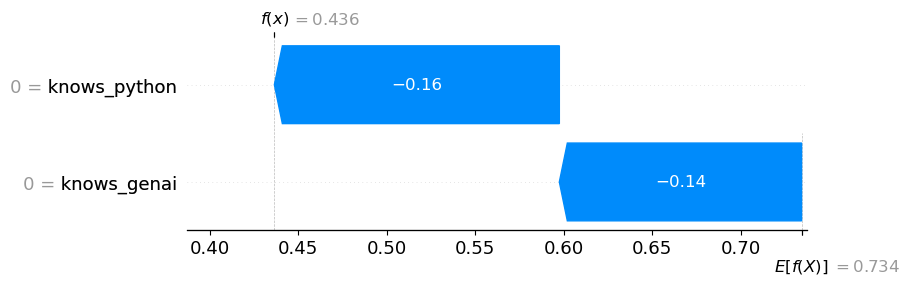

In [32]:
shap.plots.waterfall(shap_values_row1[0])

---

In [33]:
# shap for first row

shap_values_row2 = explainer(row2)
print(shap_values_row2, '\n\n\n', shap_values_row2.shape)

.values =
array([[ 0.31442038, -0.20974523]])

.base_values =
array([0.73438366])

.data =
array([[1., 0.]]) 


 (1, 2)


In [34]:
display(row2)
print(f"Row prediction: {gb.predict(row2)}")
print(f"Row prediction: {gb.predict_proba(row2)}")
print(f"Baseline prediction: {shap_values_row2.base_values.item()}")
print(f"Shap values (knows_python, knows_genai): {shap_values_row2.values.ravel()}")

,knows_python,knows_genai
846,1.0,0.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [ 0.31442038 -0.20974523]


In [35]:
shap_values_row2[0]

.values =
array([ 0.31442038, -0.20974523])

.base_values =
np.float64(0.7343836608007343)

.data =
array([1., 0.])

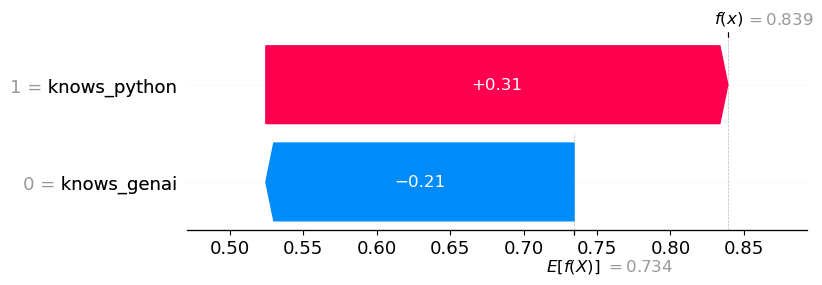

In [36]:
shap.plots.waterfall(shap_values_row2[0])

---

In [38]:
# shap for first row

shap_values_row3 = explainer(row3)
print(shap_values_row3, '\n\n\n', shap_values_row3.shape)

.values =
array([[-0.26694848,  0.37162363]])

.base_values =
array([0.73438366])

.data =
array([[0., 1.]]) 


 (1, 2)


In [39]:
display(row3)
print(f"Row prediction: {gb.predict(row3)}")
print(f"Row prediction: {gb.predict_proba(row3)}")
print(f"Baseline prediction: {shap_values_row3.base_values.item()}")
print(f"Shap values (knows_python, knows_genai): {shap_values_row3.values.ravel()}")

,knows_python,knows_genai
224,0.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [-0.26694848  0.37162363]


In [40]:
shap_values_row3[0]

.values =
array([-0.26694848,  0.37162363])

.base_values =
np.float64(0.7343836608007343)

.data =
array([0., 1.])

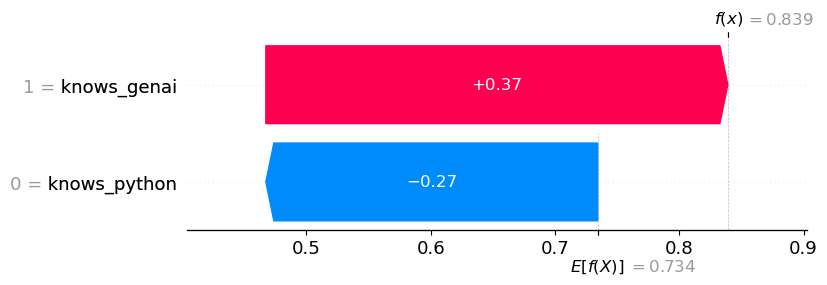

In [41]:
shap.plots.waterfall(shap_values_row3[0])

---

In [42]:
# shap for first row

shap_values_row4 = explainer(row4)
print(shap_values_row4, '\n\n\n', shap_values_row4.shape)

.values =
array([[0.05233757, 0.05233757]])

.base_values =
array([0.73438366])

.data =
array([[1., 1.]]) 


 (1, 2)


In [43]:
display(row4)
print(f"Row prediction: {gb.predict(row4)}")
print(f"Row prediction: {gb.predict_proba(row4)}")
print(f"Baseline prediction: {shap_values_row4.base_values.item()}")
print(f"Shap values (knows_python, knows_genai): {shap_values_row4.values.ravel()}")

,knows_python,knows_genai
679,1.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [0.05233757 0.05233757]


In [44]:
shap_values_row4[0]

.values =
array([0.05233757, 0.05233757])

.base_values =
np.float64(0.7343836608007343)

.data =
array([1., 1.])

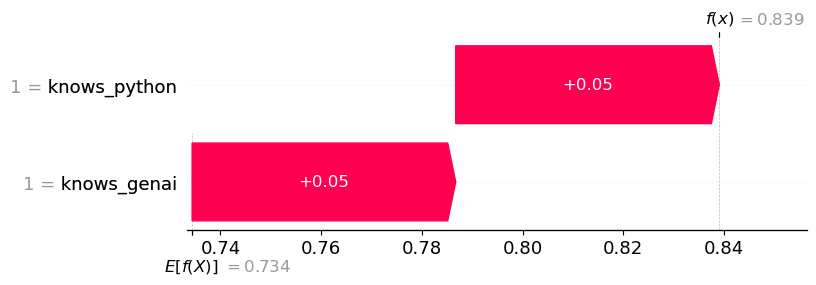

In [45]:
shap.plots.waterfall(shap_values_row4[0])

---

## changing background data to positive only

In [52]:
def calculate_and_plot_shap(model ,background_data, row):
    explainer = shap.TreeExplainer(model=model, data=background_data, model_output='probability')
    shap_values = explainer(row)
    
    display(row)
    print(f"Row prediction: {model.predict(row)}")
    print(f"Row prediction: {model.predict_proba(row)}")
    print(f"Baseline prediction: {shap_values.base_values.item()}")
    print(f"Shap values (knows_python, knows_genai): {shap_values.values.ravel()}")

    shap.plots.waterfall(shap_values[0])


,knows_python,knows_genai
552,0.0,0.0


Row prediction: [0]
Row prediction: [[0.56353792 0.43646208]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [-0.16103869 -0.13688288]


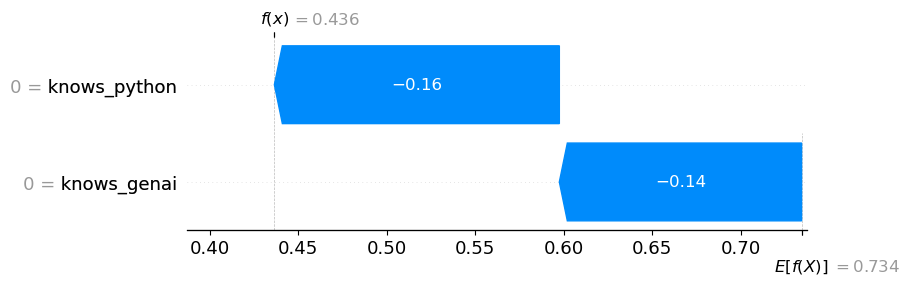

--------------------


,knows_python,knows_genai
846,1.0,0.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [ 0.31442038 -0.20974523]


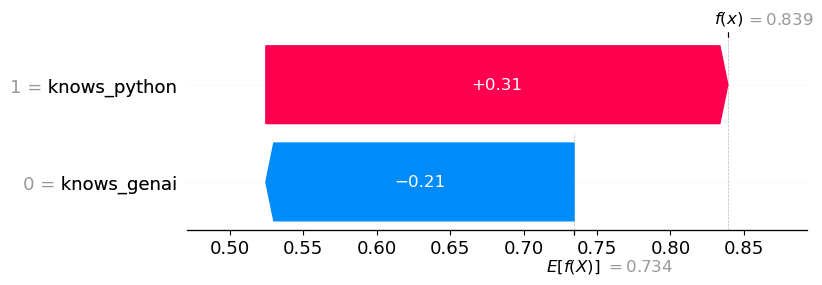

--------------------


,knows_python,knows_genai
224,0.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [-0.26694848  0.37162363]


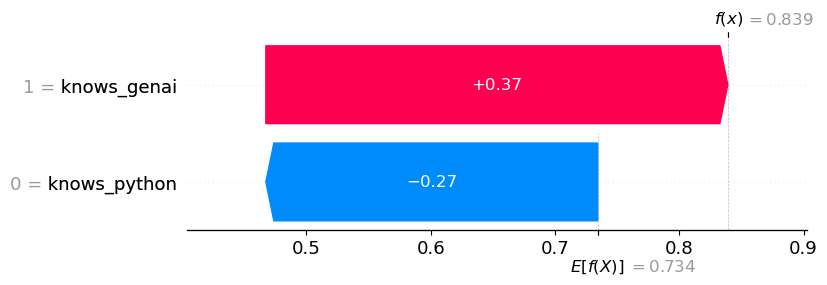

--------------------


,knows_python,knows_genai
679,1.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.7343836608007343
Shap values (knows_python, knows_genai): [0.05233757 0.05233757]


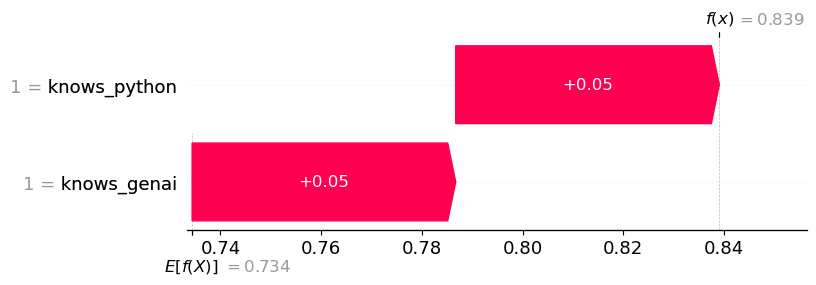

--------------------


In [55]:
for num, row in enumerate([row1, row2, row3, row4]):
    calculate_and_plot_shap(model=gb, background_data=background_data, row=row)
    print("-"*20)

,knows_python,knows_genai
552,0.0,0.0


Row prediction: [0]
Row prediction: [[0.56353792 0.43646208]]
Baseline prediction: 0.8390588094382315
Shap values (knows_python, knows_genai): [-0.18720747 -0.21538924]


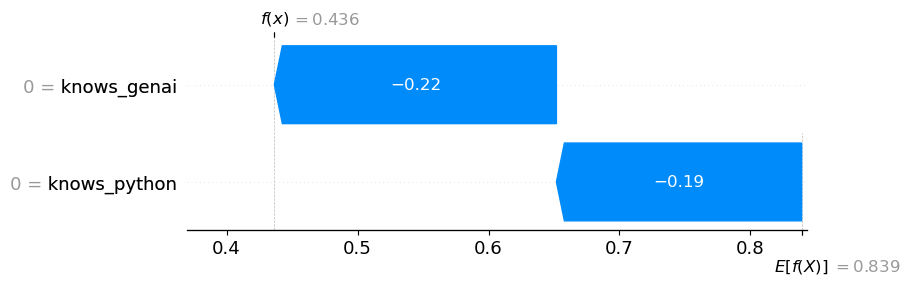

--------------------


,knows_python,knows_genai
846,1.0,0.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.8390588094382315
Shap values (knows_python, knows_genai): [ 0.31461785 -0.31461785]


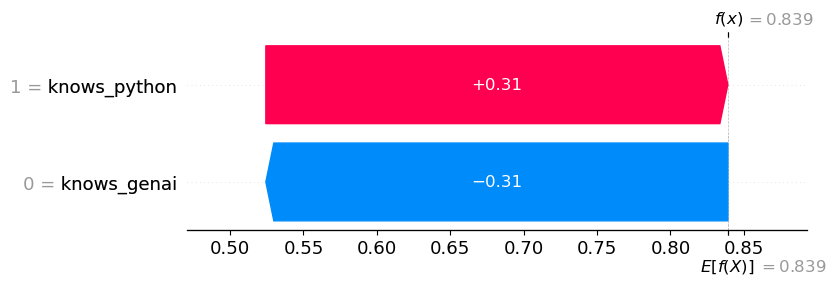

--------------------


,knows_python,knows_genai
224,0.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.8390588094382315
Shap values (knows_python, knows_genai): [-0.24788073  0.24788073]


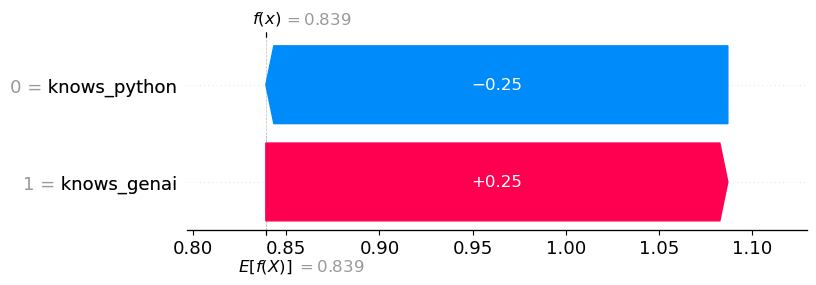

--------------------


,knows_python,knows_genai
679,1.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.8390588094382315
Shap values (knows_python, knows_genai): [0. 0.]


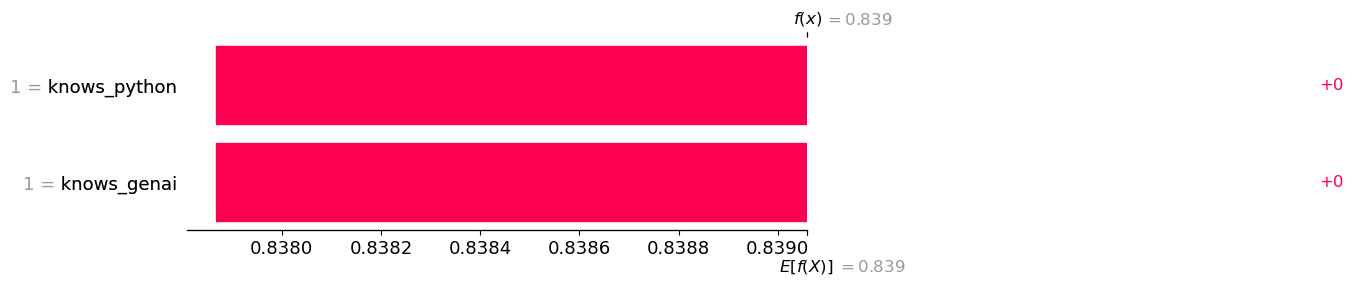

--------------------


In [56]:
# changing background data
background_data_pos = x_train.loc[y_train==1,:]

for num, row in enumerate([row1, row2, row3, row4]):
    calculate_and_plot_shap(model=gb, background_data=background_data_pos, row=row)
    print("-"*20)

,knows_python,knows_genai
552,0.0,0.0


Row prediction: [0]
Row prediction: [[0.56353792 0.43646208]]
Baseline prediction: 0.4364620839093959
Shap values (knows_python, knows_genai): [0. 0.]


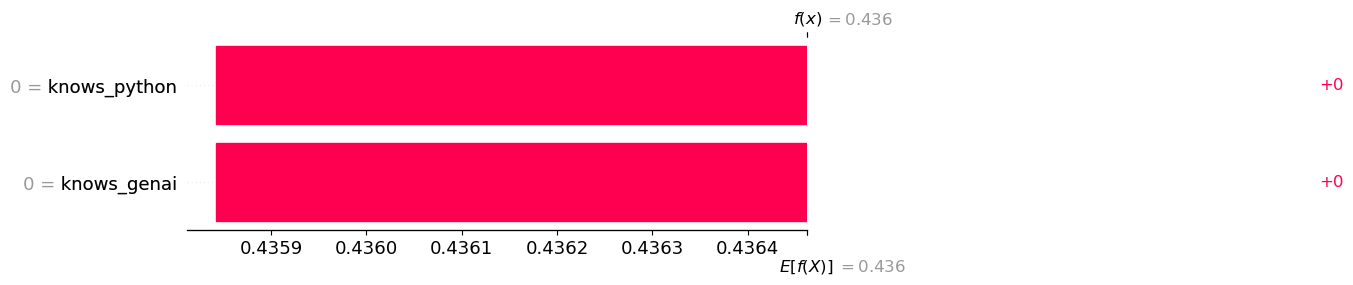

--------------------


,knows_python,knows_genai
846,1.0,0.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.4364620839093959
Shap values (knows_python, knows_genai): [0.40259672 0.        ]


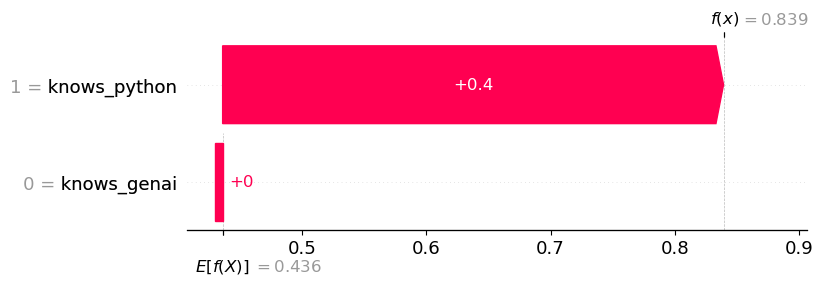

--------------------


,knows_python,knows_genai
224,0.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.4364620839093959
Shap values (knows_python, knows_genai): [0.         0.40259672]


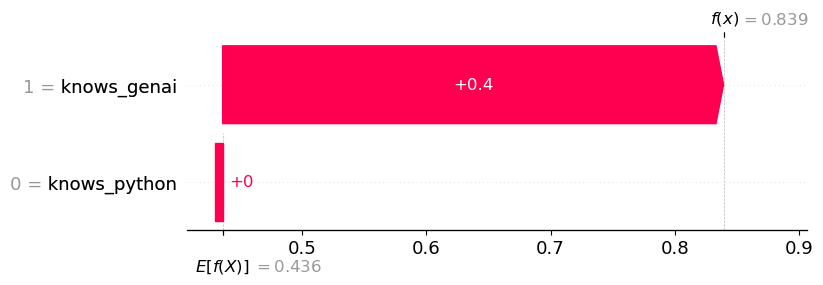

--------------------


,knows_python,knows_genai
679,1.0,1.0


Row prediction: [1]
Row prediction: [[0.16094119 0.83905881]]
Baseline prediction: 0.4364620839093959
Shap values (knows_python, knows_genai): [0.20129836 0.20129836]


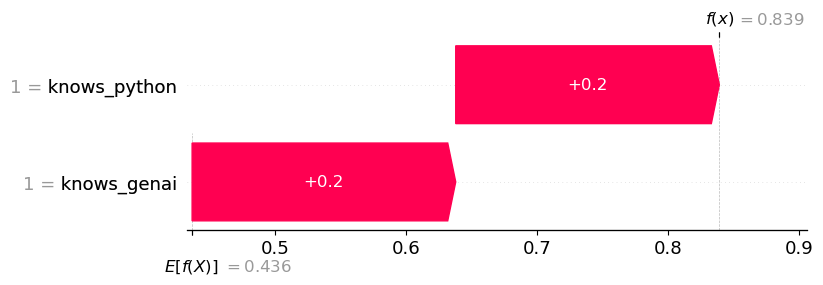

--------------------


In [57]:
# changing background data
background_data_pos = x_train.loc[y_train==0,:]

for num, row in enumerate([row1, row2, row3, row4]):
    calculate_and_plot_shap(model=gb, background_data=background_data_pos, row=row)
    print("-"*20)